<a href="https://colab.research.google.com/github/AnishRane-cox/True-Fake-News/blob/Google-Colab/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection




## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [32]:
#!pip install --upgrade numpy==1.26.4
#!pip install --upgrade pandas==2.2.2
#!pip install --upgrade nltk==3.9.1
#!pip install --upgrade spacy==3.7.5
#!pip install --upgrade scipy==1.12
#!pip install --upgrade pydantic==2.10.5
#!pip install wordcloud==1.9.4
#!python -m spacy download en_core_web_sm
#!pip install gensim

## Importing the necessary libraries

In [33]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For working with dataframes and structured data
import re  # For regular expression operations (text processing)
import nltk  # Natural Language Toolkit for text processing
import spacy  # For advanced NLP tasks
import string  # For handling string-related operations
import gensim.downloader as api #Convenient access to pretrained models

# Optional: Uncomment the line below to enable GPU support for spaCy (if you have a compatible GPU)
spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")
from spacy.lang.en.stop_words import STOP_WORDS

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  # Converts text into a bag-of-words model
)

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations


In [34]:
## Change the display properties of pandas to max
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# Import the first file - True.csv
true_link = '/content/drive/MyDrive/TF_News/True.csv'
true_news = pd.read_csv(true_link)

# Import the second file - Fake.csv
fake_link = '/content/drive/MyDrive/TF_News/Fake.csv'
fake_news = pd.read_csv(fake_link)

## **1.** Data Preparation  <font color = red>[10 marks]</font>





### **1.0** Data Understanding

In [37]:
# Inspect the DataFrame with True News to understand the given data
print("Size of True News - {}".format(true_news.size))
print("Shape of True News - {}\n".format(true_news.shape))
true_news.head()

Size of True News - 64251
Shape of True News - (21417, 3)



title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [38]:
true_news.describe()

,title,text,date
count,21417,21417,21417
unique,20826,21192,716
top,Factbox: Trump fills top jobs for his administration,"(Reuters) - Highlights for U.S. President Donald Trump’s administration on Thursday: The United States drops a massive GBU-43 bomb, the largest non-nuclear bomb it has ever used in combat, in Afghanistan against a series of caves used by Islamic State militants, the Pentagon says. Trump says Pyongyang is a problem that “will be taken care of” amid speculation that North Korea is on the verge of a sixth nuclear test. Military force cannot resolve tension over North Korea, China warns, while an influential Chinese newspaper urges Pyongyang to halt its nuclear program in exchange for Beijing’s protection. The Trump administration is focusing its North Korea strategy on tougher economic sanctions, possibly including intercepting cargo ships and punishing Chinese banks doing business with Pyongyang, U.S. officials say. Trump says “things will work out fine” between the United States and Russia, a day after declaring U.S.-Russian relations may be at an all-time low. Trump signals he could be moving closer to the mainstream on monetary policy, saying he has not ruled out reappointment of Janet Yellen as Federal Reserve chair as he considers his choices for the U.S. central bank. [nL1N1HL14B] Trump signs a resolution that will allow U.S. states to restrict how federal funds for contraception and reproductive health are spent, a move cheered by anti-abortion campaigners. Democratic Senator Chris Van Hollen presses Deutsche Bank to release information about issues including Trump’s debt and any bank meetings with Trump administration officials, saying he has “great concern” about possible conflicts of interest. EXPORT-IMPORT BANK Trump’s office says he plans to revive the hobbled Export-Import Bank of the United States, a victory for American manufacturers such as Boeing Co and General Electric Co that have overseas customers that use the agency’s government-backed loans to purchase their products. Top Wall Street bankers say they are having positive discussions about financial regulation in Washington, and downplay the idea U.S. policymakers may force their institutions to split up. The United States is pushing for trade to be a key issue in top-level economic talks with Japan, a source says, an unwelcome development for Tokyo, which is seeking to fend off U.S. pressure to reduce the bilateral trade imbalance. Trump’s administration has focused on one group of illegal immigrants more than others: women with children, according to eight Department of Homeland Security officials interviewed by Reuters about agency planning.","December 20, 2017"
freq,14,8,182


In [39]:
# Inspect the DataFrame with Fake News to understand the given data
print("Size of True News - {}".format(fake_news.size))
print("Shape of True News - {}\n".format(fake_news.shape))
fake_news.head()

Size of True News - 70569
Shape of True News - (23523, 3)



,title,text,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year! Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress. Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me? Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish?? Marlene (@marlene399) December 31, 2017You can t just say happy new year? Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love! Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his enemies and haters for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President? Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down. Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters? Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.","December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher Steele-dossier was what prompted the Russia investigation so he s been lashing out at the Department of Justice and the FBI in order to protect Trump. As it happens, the dossier is not what started the investigation, according to documents obtained by the New York Times.Former Trump campaign adviser George Papadopoulos was drunk in a wine bar when he revealed knowledge of Russian opposition research on Hillary Clinton.On top of that, Papadopoulos wasn t just a covfefe boy for Trump, as his administration has alleged. He had a much larger role, but none so damning as being a drunken fool in a wine bar. Coffee boys don t help to arrange a New York meeting between Trump and President Abdel Fattah el-Sisi of Egypt two months before the election. It was known before that the former

In [40]:
fake_news.describe()

,title,text,date
count,23502,23502,23481
unique,17914,17466,1692
top,MEDIA IGNORES Time That Bill Clinton FIRED His FBI Director On Day Before Vince Foster Was Found Dead,,"May 10, 2017"
freq,6,626,46


In [41]:
# Print the column details for True News DataFrame
true_news.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   21417 non-null  object
 1   text    21417 non-null  object
 2   date    21417 non-null  object
dtypes: object(3)
memory usage: 502.1+ KB


In [42]:
# Print the column details for Fake News Dataframe
fake_news.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23502 non-null  object
 1   text    23502 non-null  object
 2   date    23481 non-null  object
dtypes: object(3)
memory usage: 551.4+ KB


In [43]:
# Print the column names of both DataFrames
print("True News Columns Names - {}".format(true_news.columns))
print("Fake News Columns Names - {}".format(fake_news.columns))

True News Columns Names - Index(['title', 'text', 'date'], dtype='object')
Fake News Columns Names - Index(['title', 'text', 'date'], dtype='object')


### **1.1** Add new column  <font color = red>[3 marks]</font> <br>

Add new column `news_label` to both the DataFrames and assign labels

In [44]:
# Add a new column 'news_label' to the true news DataFrame and assign the label "1" to indicate that these news are true
true_news['news_label'] = 1
# Add a new column 'news_label' to the fake news DataFrame and assign the label "0" to indicate that these news are fake
fake_news['news_label'] = 0

In [45]:
# Print the column names of both DataFrames
print("True News Columns Names - {}".format(true_news.columns))
print("Fake News Columns Names - {}".format(fake_news.columns))

True News Columns Names - Index(['title', 'text', 'date', 'news_label'], dtype='object')
Fake News Columns Names - Index(['title', 'text', 'date', 'news_label'], dtype='object')


### **1.2** Merge DataFrames  <font color = red>[2 marks]</font> <br>

Create a new Dataframe by merging True and Fake DataFrames

In [46]:
# Combine the true and fake news DataFrames into a single DataFrame
comb_df = pd.concat([true_news, fake_news], axis = 0, ignore_index = True)

In [47]:
# Display the first 5 rows of the combined DataFrame to verify the result
comb_df.head()

title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [48]:
comb_df.tail()

title  \
44935                          McPain: John McCain Furious That Iran Treated US Sailors Well   
44936      JUSTICE? Yahoo Settles E-mail Privacy Class-action: $4M for Lawyers, $0 for Users   
44937  Sunnistan: US and Allied ‘Safe Zone’ Plan to Take Territorial Booty in Northern Syria   
44938                    How to Blow $700 Million: Al Jazeera America Finally Calls it Quits   
44939      10 U.S. Navy Sailors Held by Iranian Military – Signs of a Neocon Political Stunt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

### **1.3** Handle the null values  <font color = red>[2 marks]</font> <br>

Check for null values and handle it by imputation or dropping the null values

In [49]:
# Check Presence of Null Values
print(comb_df.isnull().sum())

title         21
text          21
date          42
news_label     0
dtype: int64


In [50]:
# Handle Rows with Null Values
comb_df = comb_df.dropna(subset=['title', 'text'])

In [51]:
print(comb_df.isnull().sum())

title          0
text           0
date          21
news_label     0
dtype: int64


In [52]:
comb_df['date'] = pd.to_datetime(comb_df['date'], errors='coerce')

In [53]:
comb_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 44919 entries, 0 to 44939
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   title       44919 non-null  object        
 1   text        44919 non-null  object        
 2   date        21417 non-null  datetime64[ns]
 3   news_label  44919 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1.7+ MB


### **1.4** Merge the relevant columns and drop the rest from the DataFrame  <font color = red>[3 marks]</font> <br>

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [54]:
# Combine the relevant columns into a new column 'news_text' by joining their values with a space
comb_df['news_text'] = comb_df['title']+' '+comb_df['text']
# Drop the irrelevant columns from the DataFrame as they are no longer needed
comb_news = comb_df.drop(columns = ['date'])
# Display the first 5 rows of the updated DataFrame to check the result
comb_news.head()

title  \
0       As U.S. budget fight looms, Republicans flip their fiscal script   
1       U.S. military to accept transgender recruits on Monday: Pentagon   
2           Senior U.S. Republican senator: 'Let Mr. Mueller do his job'   
3            FBI Russia probe helped by Australian diplomat tip-off: NYT   
4  Trump wants Postal Service to charge 'much more' for Amazon shipments   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## **2.** Text Preprocessing <font color = red>[15 marks]</font> <br>






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning  <font color = red>[5 marks]</font> <br>



#### 2.1.0 Create a new DataFrame to store the processed data



In [55]:
# Create a DataFrame('df_clean') that will have only the cleaned news text and the lemmatized news text with POS tags removed
# Add 'news_label' column to the new dataframe for topic identification
df_clean = comb_news[['news_text', 'news_label']].copy()

In [56]:
df_clean.head()

news_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        As U.S. budget fight looms, Republicans flip their fiscal script WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want proportional increases for non-defense “discretionary” spending on programs that support education, scientific research, infrastructure, public health and environmental protection. “The (Trump) administration has already been willing to say: ‘We’re going to increase non-defense discretionary spending ... by about 7 percent,’” Meadows, chairman of the small but influential House Freedom Caucus, said on the program. “Now, Democrats are saying that’s not enough, we need to give the government a pay raise of 10 to 11 percent. For a fiscal conservative, I don’t see where the rationale is. ... Eventually you run out of other people’s money,” he said. Meadows was among Republicans who voted in late December for their party’s debt-financed tax overhaul, which is expected to balloon the federal budget deficit and add about $1.5 trillion over 10 years to the $20 trillion national debt. “It’s interesting to hear Mark talk about fiscal responsibility,” Democratic U.S. Representative Joseph Crowley said on CBS. Crowley said the Republican tax bill would require the  United States to borrow $1.5 trillion, to be paid off by future generations, to finance tax cuts for corporations and the rich. “This is one of the least ... fiscally responsible bills we’ve ever seen passed in the history of the House of Representatives. I think we’re going to be paying for this for many, many years to come,” Crowley said. Republicans insist the tax package, the biggest U.S. tax overhaul in more than 30 years,  will boost the economy and job growth. House Speaker Paul Ryan, who also supported the tax bill, recently went further than Meadows, making clear in a radio interview that welfare or “entitlement reform,” as the party often calls it, would be a top Republican priority in 2018. In Republican parlance, “entitlement” programs mean food stamps, housing assistance, Medicare and Medicaid health insurance for the elderly, poor and disabled, as well as other programs created by Washington to assist the needy. Democrats seized on Ryan’s early December remarks, saying they showed Republicans would try to pay for their tax overhaul by seeking spending cuts for social programs. But the goals of House Republicans may have to take a back seat to the Senate, where the votes of some Democrats will be needed to approve a budget and prevent a government shutdown. Democrats will use their leverage in the Senate, which Republicans narrowly control, to defend both disc

#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements  <font color = red>[4 marks]</font> <br>



In [57]:
# Write the function here to clean the text and remove all the unnecessary elements
def clean_raw_text(text):

    # Convert to lower case
    text = text.lower()

    # Remove text in square brackets
    text = re.sub('\[.*?]','',text)

    # Remove punctuation
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)

    # Remove words containing numbers
    text = re.sub('\w*\d\w*', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame. <font color = red>[1 mark]</font> <br>


In [58]:
# Apply the function to clean the news text and remove all unnecessary elements
# Store it in a separate column in the new DataFrame
df_clean['cleaned_text'] = df_clean['news_text'].apply(clean_raw_text)

In [59]:
df_clean.head()

news_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        As U.S. budget fight looms, Republicans flip their fiscal script WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want proportional increases for non-defense “discretionary” spending on programs that support education, scientific research, infrastructure, public health and environmental protection. “The (Trump) administration has already been willing to say: ‘We’re going to increase non-defense discretionary spending ... by about 7 percent,’” Meadows, chairman of the small but influential House Freedom Caucus, said on the program. “Now, Democrats are saying that’s not enough, we need to give the government a pay raise of 10 to 11 percent. For a fiscal conservative, I don’t see where the rationale is. ... Eventually you run out of other people’s money,” he said. Meadows was among Republicans who voted in late December for their party’s debt-financed tax overhaul, which is expected to balloon the federal budget deficit and add about $1.5 trillion over 10 years to the $20 trillion national debt. “It’s interesting to hear Mark talk about fiscal responsibility,” Democratic U.S. Representative Joseph Crowley said on CBS. Crowley said the Republican tax bill would require the  United States to borrow $1.5 trillion, to be paid off by future generations, to finance tax cuts for corporations and the rich. “This is one of the least ... fiscally responsible bills we’ve ever seen passed in the history of the House of Representatives. I think we’re going to be paying for this for many, many years to come,” Crowley said. Republicans insist the tax package, the biggest U.S. tax overhaul in more than 30 years,  will boost the economy and job growth. House Speaker Paul Ryan, who also supported the tax bill, recently went further than Meadows, making clear in a radio interview that welfare or “entitlement reform,” as the party often calls it, would be a top Republican priority in 2018. In Republican parlance, “entitlement” programs mean food stamps, housing assistance, Medicare and Medicaid health insurance for the elderly, poor and disabled, as well as other programs created by Washington to assist the needy. Democrats seized on Ryan’s early December remarks, saying they showed Republicans would try to pay for their tax overhaul by seeking spending cuts for social programs. But the goals of House Republicans may have to take a back seat to the Senate, where the votes of some Democrats will be needed to approve a budget and prevent a government shutdown. Democrats will use their leverage in the Senate, which Republicans narrowly control, to defend both disc

### **2.2** POS Tagging and Lemmatization  <font color = red>[10 marks]</font> <br>



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags <font color = red>[8 marks]</font> <br>



In [60]:
def POS_Lemm_Func(text):
    doc = nlp(text)
    common_nouns = [
        token.lemma_.lower() for token in doc
        if token.tag_ in ("NN", "NNS") and token.lemma_.lower() not in STOP_WORDS # Removing stop words and Doing POS tagging at the same time.
    ]
    return common_nouns

#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame. <font color = red>[2 mark]</font> <br>

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [61]:
# Apply POS tagging and lemmatization function to cleaned text
# Store it in a separate column in the new DataFrame
df_clean['lemm_n'] = df_clean['cleaned_text'].apply(POS_Lemm_Func)

In [62]:
# Deep learning or sequence-based models, storing full processed strings might be more suitable:
df_clean['lemm_str'] = df_clean['lemm_n'].apply(lambda x: ' '.join(x))

In [63]:
print(df_clean.isnull().sum())

news_text       0
news_label      0
cleaned_text    0
lemm_n          0
lemm_str        0
dtype: int64


### Save the Cleaned data as a csv file (Recommended)

In [64]:
## Recommended to perform the below steps to save time while rerunning the code
df_clean.to_csv("/content/drive/MyDrive/TF_News/clean_df.csv", index=False)

In [65]:
df_clean = pd.read_csv("/content/drive/MyDrive/TF_News/clean_df.csv")

In [66]:
# Check the dimensions of the DataFrame
df_clean.shape

(44919, 5)

In [67]:
# Check the number of non-null entries and data types of each column
print(df_clean.isnull().sum(),'\n')
df_clean.info(verbose=True)

news_text        0
news_label       0
cleaned_text     9
lemm_n           0
lemm_str        21
dtype: int64 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44919 entries, 0 to 44918
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   news_text     44919 non-null  object
 1   news_label    44919 non-null  int64 
 2   cleaned_text  44910 non-null  object
 3   lemm_n        44919 non-null  object
 4   lemm_str      44898 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


## **3.** Train Validation Split <font color = red>[5 marks]</font> <br>

In [68]:
# Import Train Test Split and split the DataFrame into 70% train and 30% validation data
train_df, val_df = train_test_split(df_clean, test_size=0.3, random_state=42, stratify=df_clean['news_label'])
# stratify=df['label'] → keeps the label distribution balanced (very important for classification)

## **4.** Exploratory Data Analysis on Training Data  <font color = red>[40 marks]</font> <br>

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed  <font color = red>[10 marks]</font> <br>



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns  <font color = red>[3 marks]</font> <br>



In [69]:
train_df.head()

news_text  \
23048                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           WATCH: Neo-Nazi Leader Regrets His Trump Vote, Blames ‘Jewish Lobby’ For Failure To Build Wall This weekend, neo-Nazis and white supremacists gathered in eastern Kentucky. On Friday, Art Jones addressed the group. The Anti-Defamation League (ADL) has identified Jones as a denier of the Holocaust. Since the 1970s, he has been dressing up on Nazi attire and celebrating Hitler and the ideals of the Third Reich. He is now upset with President Donald Trump and wishes he could take his vote back.Jones told the crowd: I m sorry I voted for the son of a bitch, I really am. I m sorry I spent $180 out of my own po

In [70]:
# Add a new column to calculate the character length of cleaned news text
train_df['cleaned_text_length'] = train_df['cleaned_text'].str.len()
# Add a new column to calculate the character length of lemmatized news text with POS tags removed
train_df['lemm_nouns_length'] = train_df['lemm_str'].str.len()

##### 4.1.2  Create Histogram to visualise character lengths  <font color = red>[7 marks]</font> <br>

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

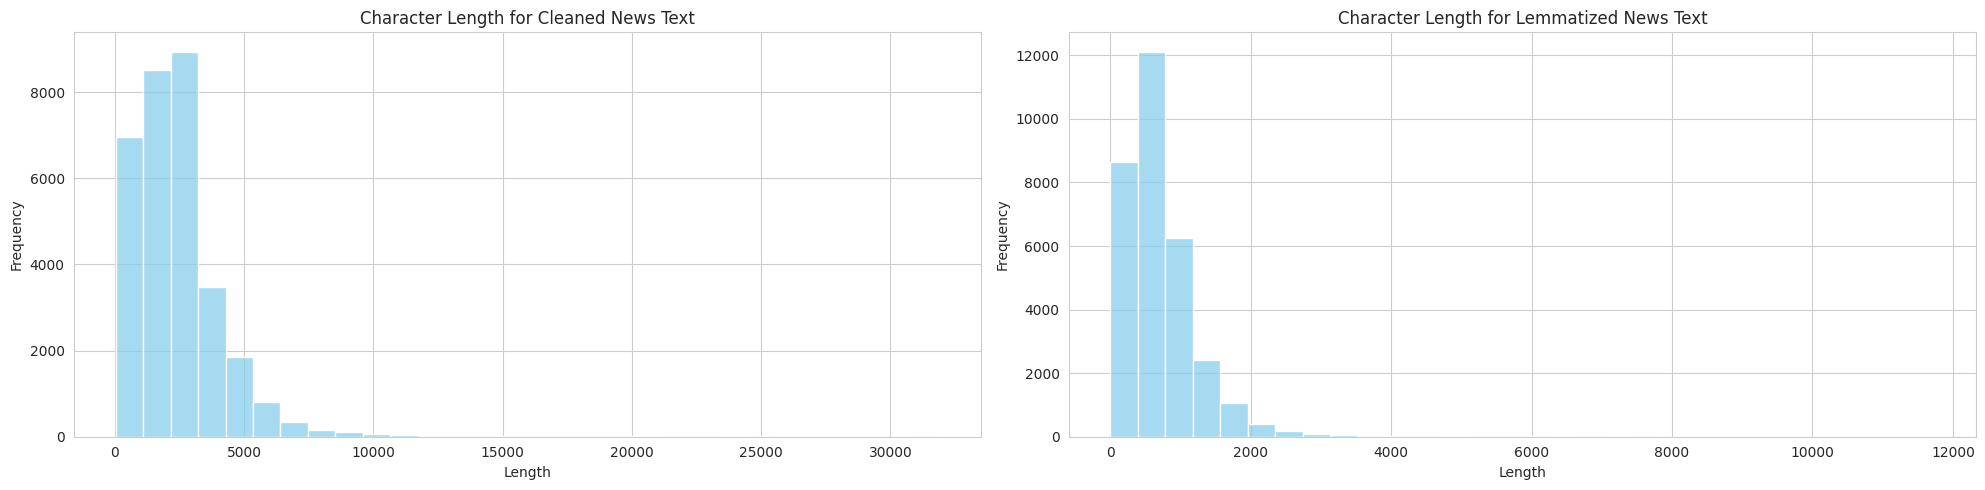

In [71]:
sns.set_style('whitegrid')
plt.figure(figsize=(20,5))

# Create a histogram plot to visualise character lengths

# Add histogram for cleaned news text
plt.subplot(1, 2, 1)
sns.histplot(train_df['cleaned_text_length'], bins = 30, color = 'skyblue')
plt.title('Character Length for Cleaned News Text')
plt.xlabel('Length')
plt.ylabel('Frequency')

# Add histogram for lemmatized news text with POS tags removed
plt.subplot(1, 2, 2)
sns.histplot(train_df['lemm_nouns_length'], bins = 30, color = 'skyblue')
plt.title('Character Length for Lemmatized News Text')
plt.xlabel('Length')
plt.ylabel('Frequency')

# Display both plots
plt.tight_layout()
plt.show()

### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text  <font color = red>[10 marks]</font> <br>



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

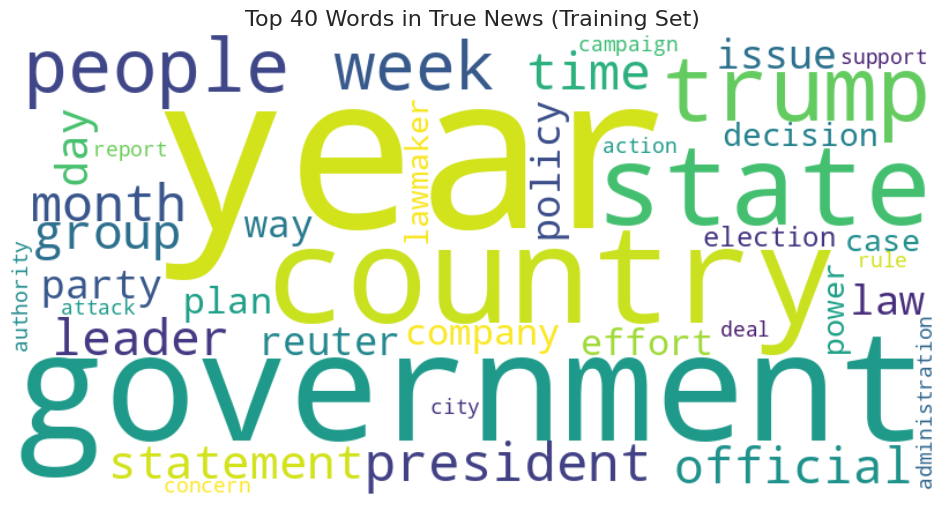

In [72]:
## Use a word cloud find the top 40 words by frequency among true news in the training data after processing the text

# Filter news with label 1 (True News) and convert to it string and handle any non-string values
true_news_texts = train_df[train_df['news_label'] == 1]['lemm_str']

# Ensure all entries are strings and join them into one big string
true_news_combined = ' '.join(true_news_texts.dropna().astype(str))

# Generate word cloud for True News
wordcloud = WordCloud(
    width=800, height=400,
    max_words=40,
    background_color='white',
    colormap='viridis'
).generate(true_news_combined)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 40 Words in True News (Training Set)', fontsize=16)
plt.show()

##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

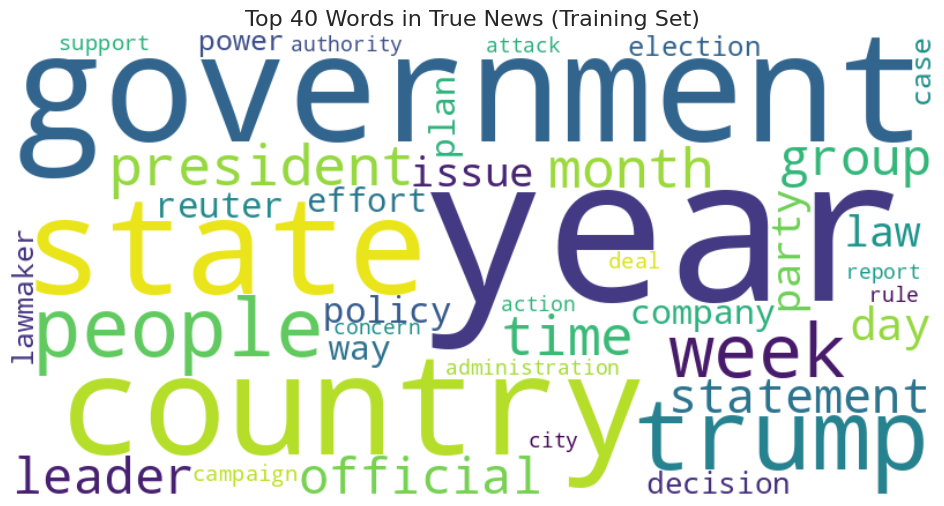

In [73]:
## Use a word cloud find the top 40 words by frequency among fake news in the training data after processing the text

# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values
fake_news_texts = train_df[train_df['news_label'] == 0]['lemm_str']

# Ensure all entries are strings and join them into one big string
fake_news_combined = ' '.join(fake_news_texts.dropna().astype(str))

# Generate word cloud for Fake News
wordcloud = WordCloud(
    width=800, height=400,
    max_words=40,
    background_color='white',
    colormap='viridis'
).generate(true_news_combined)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 40 Words in True News (Training Set)', fontsize=16)
plt.show()

### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  <font color = red>[20 marks]</font> <br>




##### 4.3.1 Write a function to get the specified top n-grams  <font color = red>[4 marks]</font> <br>



In [74]:
def plot_top_ngrams_by_label(df, text_col, label_col, label_value, ngram_range=(1, 1), n=10, title='Top N-grams'):
    """
    Extracts top n-grams from a specific label class and plots them.

    Parameters:
    - df: DataFrame
    - text_col: column name containing preprocessed text
    - label_col: column name containing labels
    - label_value: the specific label to filter (e.g. 1 for True news)
    - ngram_range: tuple (min_n, max_n) for n-grams
    - n: top N n-grams to display
    - title: plot title
    """
    # Extract subset
    corpus = df[df[label_col] == label_value][text_col].dropna().tolist()

    # Get top n-grams
    from sklearn.feature_extraction.text import CountVectorizer
    from collections import Counter

    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(corpus)
    ngram_freq = X.toarray().sum(axis=0)
    vocab = vectorizer.get_feature_names_out()

    ngram_counts = pd.DataFrame({
        'ngram': vocab,
        'count': ngram_freq
    }).sort_values(by='count', ascending=False).head(n)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=ngram_counts, x='count', y='ngram', palette='viridis')
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel(f"{ngram_range[1]}-gram")
    plt.tight_layout()
    plt.show()


##### 4.3.2 Handle the NaN values  <font color = red>[1 mark]</font> <br>



In [75]:
# Handle NaN values in the text data
print(train_df.isnull().sum())  # See if any NaNs remain

news_text               0
news_label              0
cleaned_text            6
lemm_n                  0
lemm_str               17
cleaned_text_length     6
lemm_nouns_length      17
dtype: int64


In [76]:
train_df = train_df.dropna(subset=['cleaned_text', 'lemm_str']).reset_index(drop=True)

### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

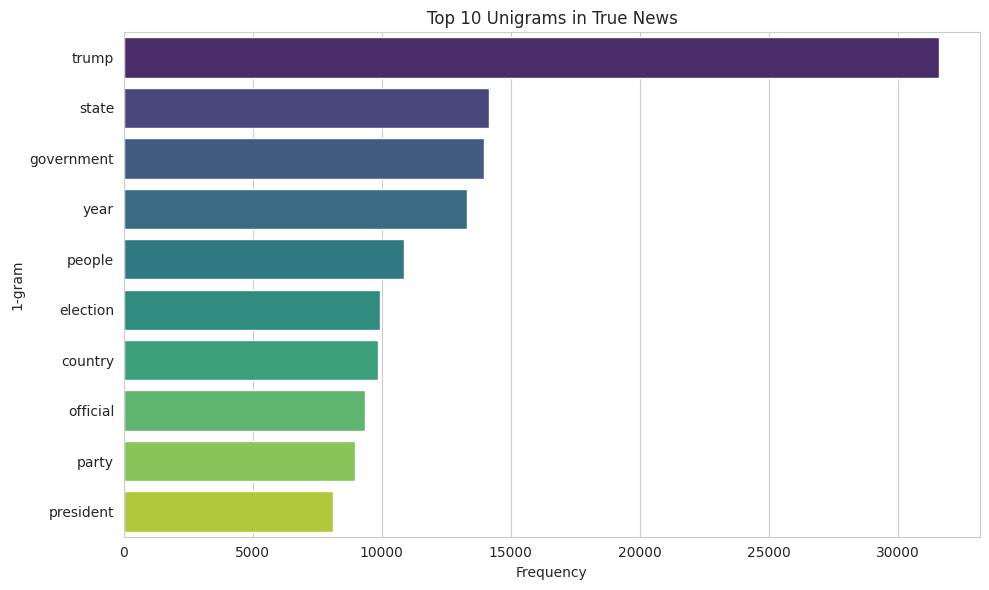

In [77]:
# Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=train_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=1,  # True news
    ngram_range=(1, 1),
    n=10,
    title='Top 10 Unigrams in True News'
)


##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



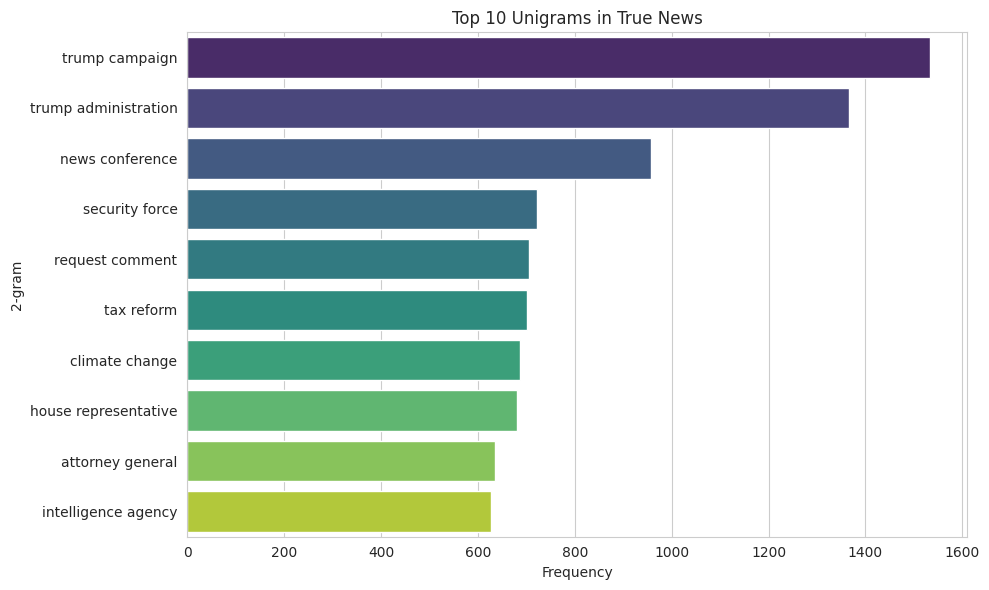

In [78]:
# Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=train_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=1,  # True news
    ngram_range=(2, 2),
    n=10,
    title='Top 10 Unigrams in True News'
)

##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



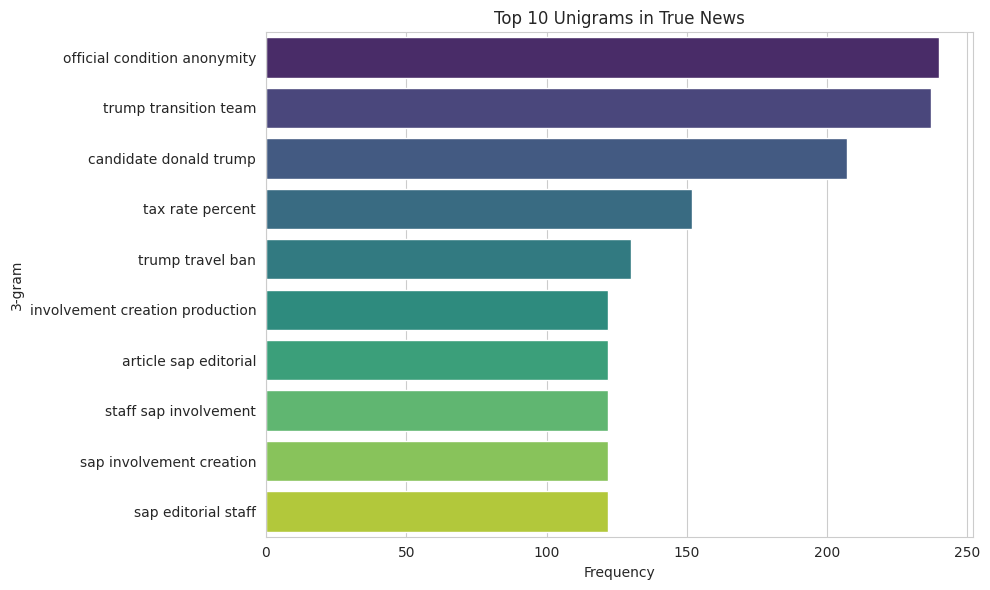

In [79]:
# Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=train_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=1,  # True news
    ngram_range=(3, 3),
    n=10,
    title='Top 10 Unigrams in True News'
)

### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

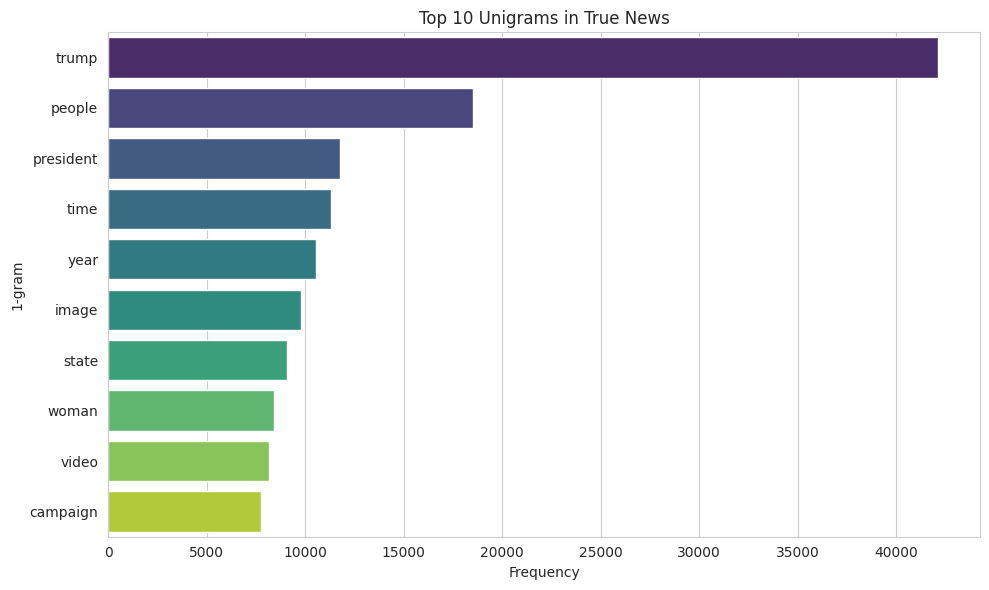

In [80]:
# Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=train_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=0,  # True news
    ngram_range=(1, 1),
    n=10,
    title='Top 10 Unigrams in True News'
)

##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



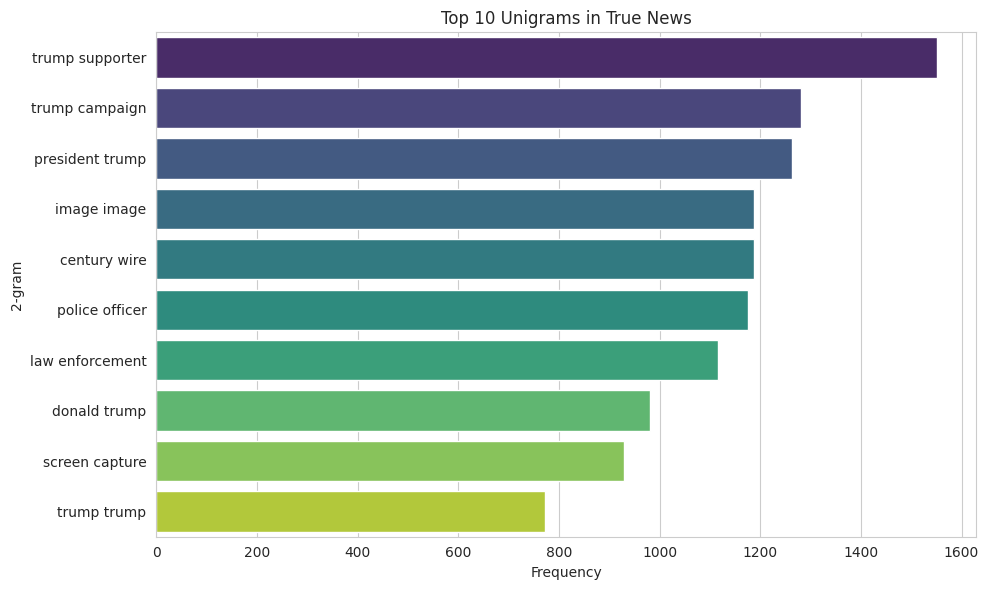

In [81]:
# Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=train_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=0,  # True news
    ngram_range=(2, 2),
    n=10,
    title='Top 10 Unigrams in True News'
)

##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>



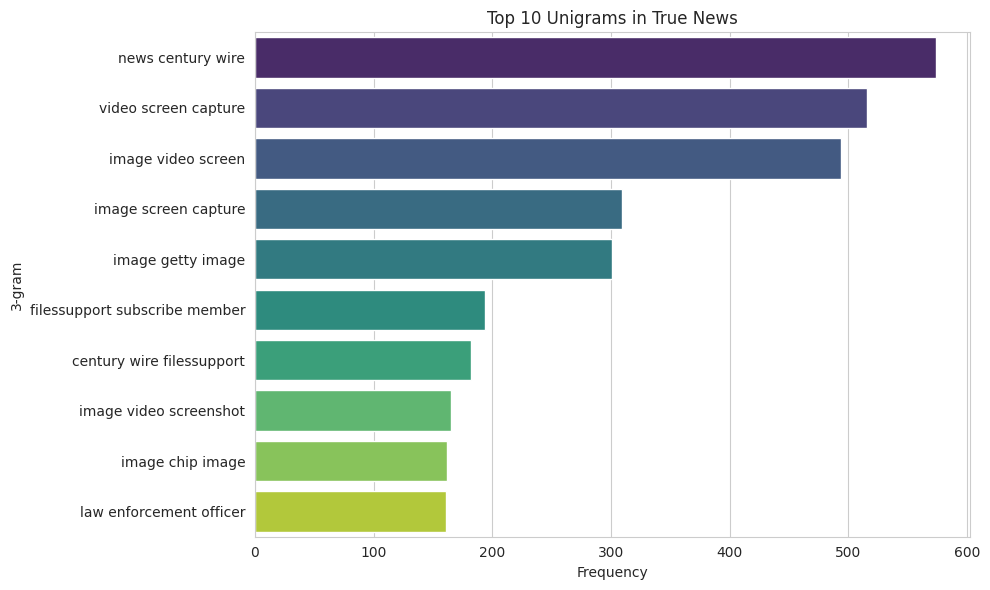

In [82]:
# Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=train_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=0,  # True news
    ngram_range=(3, 3),
    n=10,
    title='Top 10 Unigrams in True News'
)

## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [83]:
# Add a new column to calculate the character length of cleaned news text
val_df['cleaned_text_length'] = val_df['cleaned_text'].str.len()
# Add a new column to calculate the character length of lemmatized news text with POS tags removed
val_df['lemm_nouns_length'] = val_df['lemm_str'].str.len()

##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

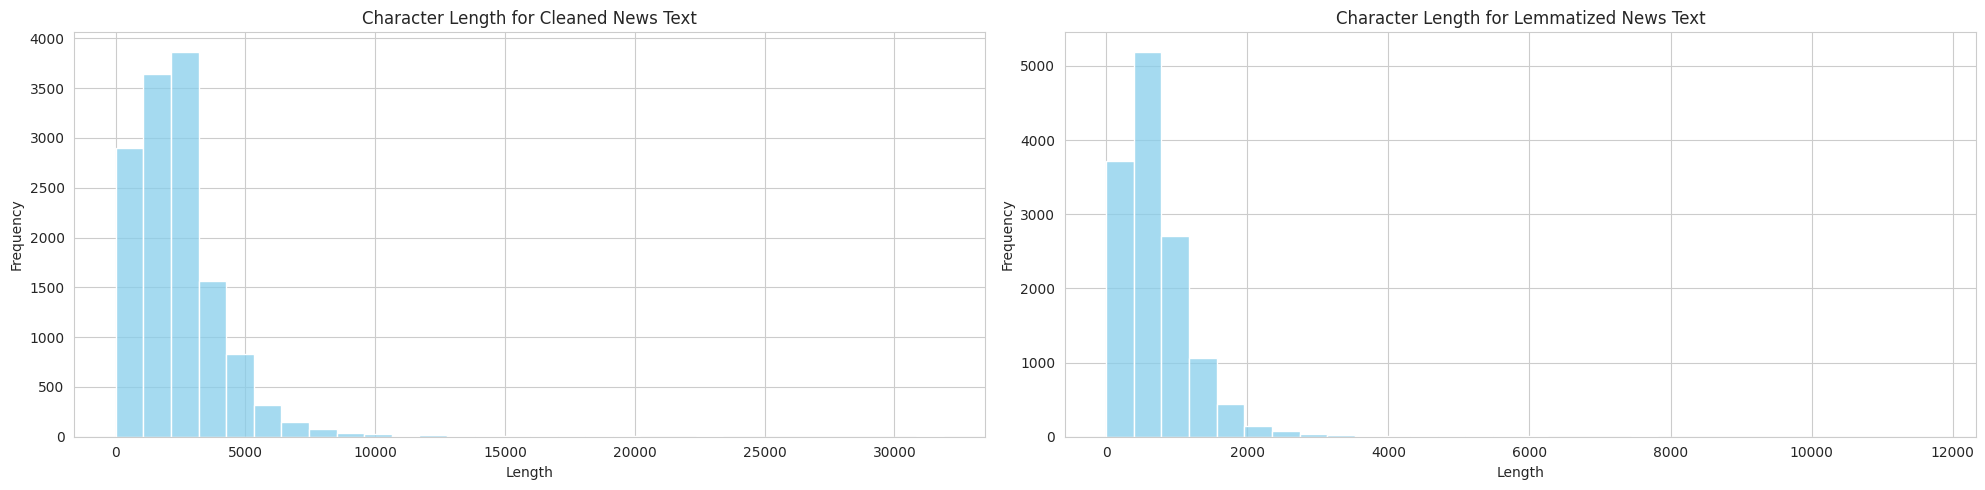

In [84]:
sns.set_style('whitegrid')
plt.figure(figsize=(20,5))

# Create a histogram plot to visualise character lengths

# Add histogram for cleaned news text
plt.subplot(1, 2, 1)
sns.histplot(val_df['cleaned_text_length'], bins = 30, color = 'skyblue')
plt.title('Character Length for Cleaned News Text')
plt.xlabel('Length')
plt.ylabel('Frequency')

# Add histogram for lemmatized news text with POS tags removed
plt.subplot(1, 2, 2)
sns.histplot(val_df['lemm_nouns_length'], bins = 30, color = 'skyblue')
plt.title('Character Length for Lemmatized News Text')
plt.xlabel('Length')
plt.ylabel('Frequency')

# Display both plots
plt.tight_layout()
plt.show()

### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

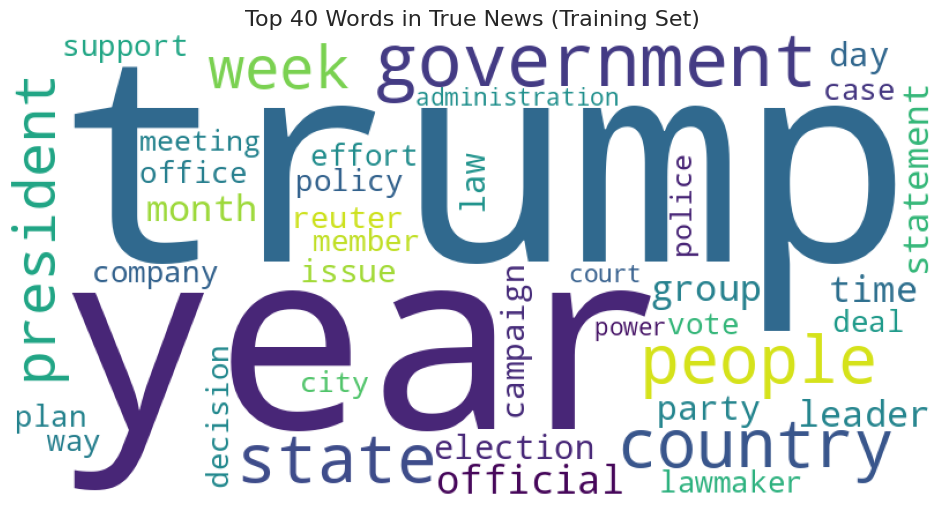

In [85]:
## Use a word cloud find the top 40 words by frequency among true news in the Test data after processing the text

# Filter news with label 1 (True News) and convert to it string and handle any non-string values
true_news_texts = val_df[val_df['news_label'] == 1]['lemm_str']

# Ensure all entries are strings and join them into one big string
true_news_combined = ' '.join(true_news_texts.dropna().astype(str))

# Generate word cloud for True News
wordcloud = WordCloud(
    width=800, height=400,
    max_words=40,
    background_color='white',
    colormap='viridis'
).generate(true_news_combined)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Top 40 Words in True News (Training Set)', fontsize=16)
plt.show()

##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

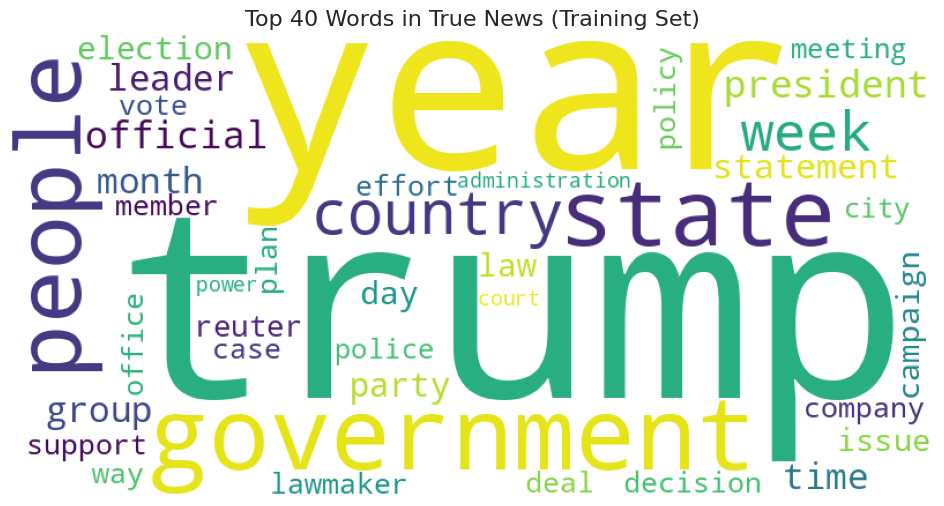

In [86]:
## Use a word cloud find the top 40 words by frequency among Fake news in the Test data after processing the text

# Filter news with label 1 (True News) and convert to it string and handle any non-string values
fake_news_texts = val_df[val_df['news_label'] == 0]['lemm_str']

# Ensure all entries are strings and join them into one big string
fake_news_combined = ' '.join(fake_news_texts.dropna().astype(str))

# Generate word cloud for True News
wordcloud = WordCloud(
    width=800, height=400,
    max_words=40,
    background_color='white',
    colormap='viridis'
).generate(true_news_combined)

# Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Top 40 Words in True News (Training Set)', fontsize=16)
plt.show()

### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [87]:
## Write a function to get the specified top n-grams
#plot_top_ngrams_by_label()

##### 5.3.2 Handle the NaN values

In [88]:
## First handle NaN values in the text data
print(val_df.isnull().sum())

news_text              0
news_label             0
cleaned_text           3
lemm_n                 0
lemm_str               4
cleaned_text_length    3
lemm_nouns_length      4
dtype: int64


In [89]:
val_df = val_df.dropna(subset=['cleaned_text', 'lemm_str']).reset_index(drop=True)

### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

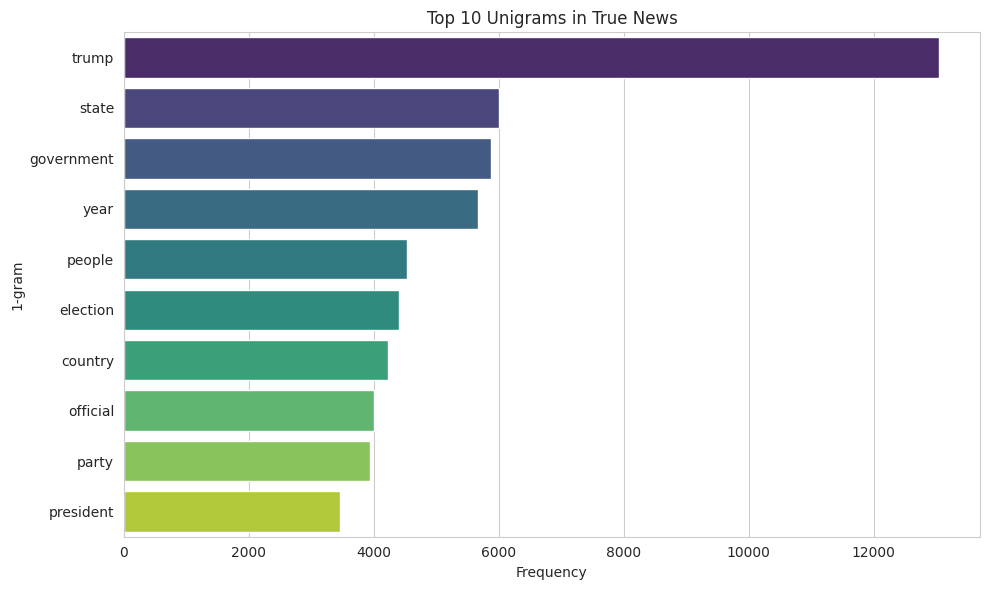

In [90]:
## Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=val_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=1,  # True news
    ngram_range=(1, 1),
    n=10,
    title='Top 10 Unigrams in True News'
)

##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

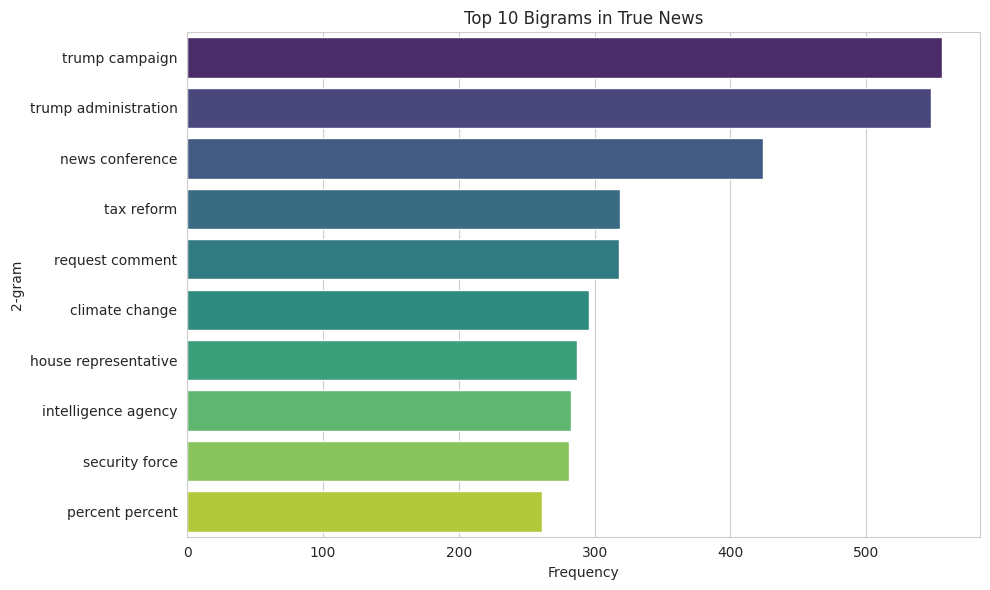

In [91]:
## Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=val_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=1,  # True news
    ngram_range=(2, 2),
    n=10,
    title='Top 10 Bigrams in True News'
)


##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

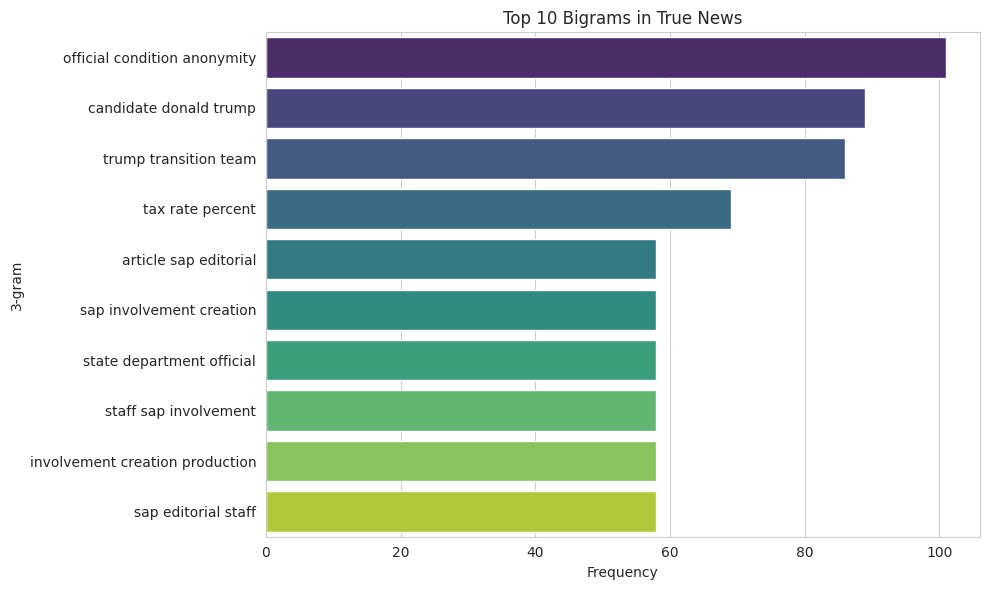

In [92]:
## Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=val_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=1,  # True news
    ngram_range=(3, 3),
    n=10,
    title='Top 10 Bigrams in True News'
)

### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

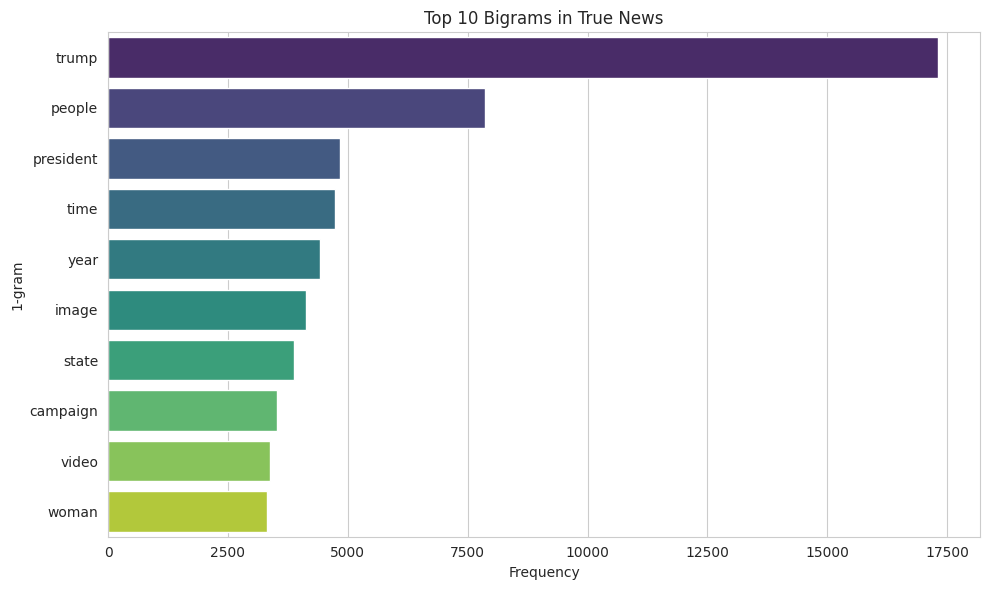

In [93]:
## Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=val_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=0,  # True news
    ngram_range=(1, 1),
    n=10,
    title='Top 10 Bigrams in True News'
)

##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

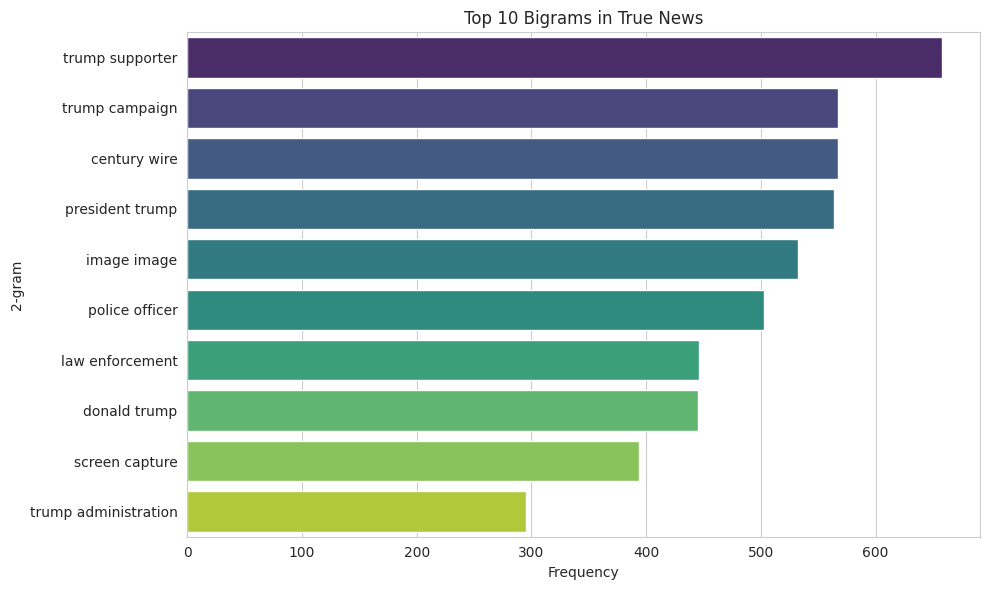

In [94]:
## Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=val_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=0,  # True news
    ngram_range=(2, 2),
    n=10,
    title='Top 10 Bigrams in True News'
)

##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

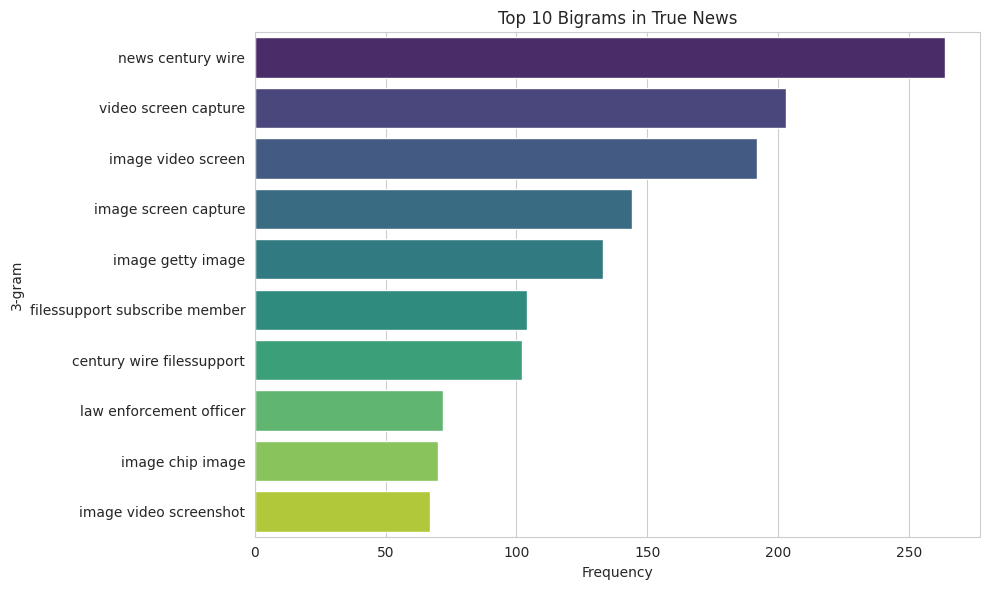

In [95]:
## Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
plot_top_ngrams_by_label(
    df=val_df,
    text_col='lemm_str',
    label_col='news_label',
    label_value=0,  # True news
    ngram_range=(3, 3),
    n=10,
    title='Top 10 Bigrams in True News'
)

## **6.** Feature Extraction  <font color = red>[10 marks]</font> <br>

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model  <font color = red>[2 marks]</font>

In [96]:
## Write your code here to initialise the Word2Vec model by downloading "word2vec-google-news-300"

word2vec = api.load('word2vec-google-news-300')

def get_avg_w2v_vector(text, model, vector_size=300):
    words = text.split()
    valid_vectors = [model[word] for word in words if word in model.key_to_index] #skip rare words not in the vocabulary automatically

    if valid_vectors:
        return np.mean(valid_vectors, axis=0)
    else:
        return np.zeros(vector_size)

[==================================================] 100.0% 1662.8/1662.8MB downloaded


### **6.2** Extract vectors for cleaned news data   <font color = red>[8 marks]</font>

In [97]:
print(train_df.isnull().sum())

news_text              0
news_label             0
cleaned_text           0
lemm_n                 0
lemm_str               0
cleaned_text_length    0
lemm_nouns_length      0
dtype: int64


In [98]:
train_df.head(2)

news_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           WATCH: Neo-Nazi Leader Regrets His Trump Vote, Blames ‘Jewish Lobby’ For Failure To Build Wall This weekend, neo-Nazis and white supremacists gathered in eastern Kentucky. On Friday, Art Jones addressed the group. The Anti-Defamation League (ADL) has identified Jones as a denier of the Holocaust. Since the 1970s, he has been dressing up on Nazi attire and celebrating Hitler and the ideals of the Third Reich. He is now upset with President Donald Trump and wishes he could take his vote back.Jones told the crowd: I m sorry I voted for the son of a bitch, I really am. I m sorry I spent $180 out of my own pocket

In [99]:
## Write your code here to extract the vectors from the Word2Vec model for both training and validation data

# Fill missing values to avoid issues during vectorization
train_df['lemm_str'] = train_df['lemm_str'].fillna('')
val_df['lemm_str'] = val_df['lemm_str'].fillna('')

# Generate Word2Vec vectors from lemmatized strings
train_df['w2v_vector'] = train_df['lemm_str'].apply(lambda x: get_avg_w2v_vector(x, word2vec))
val_df['w2v_vector'] = val_df['lemm_str'].apply(lambda x: get_avg_w2v_vector(x, word2vec))

# Convert list of vectors to a 2D NumPy array for model training
X_train = np.vstack(train_df['w2v_vector'].values)
X_val = np.vstack(val_df['w2v_vector'].values)

# Extract the labels
y_train = train_df['news_label'].values
y_val = val_df['news_label'].values

In [100]:
train_df.head(2)

news_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           WATCH: Neo-Nazi Leader Regrets His Trump Vote, Blames ‘Jewish Lobby’ For Failure To Build Wall This weekend, neo-Nazis and white supremacists gathered in eastern Kentucky. On Friday, Art Jones addressed the group. The Anti-Defamation League (ADL) has identified Jones as a denier of the Holocaust. Since the 1970s, he has been dressing up on Nazi attire and celebrating Hitler and the ideals of the Third Reich. He is now upset with President Donald Trump and wishes he could take his vote back.Jones told the crowd: I m sorry I voted for the son of a bitch, I really am. I m sorry I spent $180 out of my own pocket

## **7.** Model Training and Evaluation <font color = red>[45 marks]</font>

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### **7.1** Build Logistic Regression Model  <font color = red>[15 marks]</font>

##### 7.1.1 Create and train logistic regression model on training data  <font color = red>[10 marks]</font>

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [103]:
# Initialize Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Predict on validation data
y_pred = lr_model.predict(X_val)

##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [104]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

# Print results
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9040
Precision: 0.8939
Recall:    0.9063
F1 Score:  0.9001


In [105]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91      7047
           1       0.89      0.91      0.90      6425

    accuracy                           0.90     13472
   macro avg       0.90      0.90      0.90     13472
weighted avg       0.90      0.90      0.90     13472



In [106]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1],      # Regularization strength
    'penalty': ['l2'],
    'solver': ['liblinear']
}

grid_logreg = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=3, scoring='f1_macro')
grid_logreg.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_logreg.best_params_)

# Evaluate best model
best_logreg = grid_logreg.best_estimator_
y_pred_best_logreg = best_logreg.predict(X_val_scaled)
print("Best Logistic Regression Report:")
print(classification_report(y_val, y_pred_best_logreg))

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      7047
           1       0.90      0.91      0.91      6425

    accuracy                           0.91     13472
   macro avg       0.91      0.91      0.91     13472
weighted avg       0.91      0.91      0.91     13472



### **7.2** Build Decision Tree Model <font color = red>[15 marks]</font>

##### 7.2.1 Create and train a decision tree model on training data <font color = red>[10 marks]</font>

In [107]:
# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train Decision Tree model on training data
dt_model.fit(X_train, y_train)

# Predict on validation data
y_pred_dt = dt_model.predict(X_val)

##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [108]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
accuracy = accuracy_score(y_val, y_pred_dt)
precision = precision_score(y_val, y_pred_dt)
recall = recall_score(y_val, y_pred_dt)
f1 = f1_score(y_val, y_pred_dt)

# Print results
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.8237
Precision: 0.8299
Recall:    0.7928
F1 Score:  0.8110


In [109]:
# Classification Report
print("\nClassification Report (Decision Tree):\n")
print(classification_report(y_val, y_pred_dt))


Classification Report (Decision Tree):

              precision    recall  f1-score   support

           0       0.82      0.85      0.83      7047
           1       0.83      0.79      0.81      6425

    accuracy                           0.82     13472
   macro avg       0.82      0.82      0.82     13472
weighted avg       0.82      0.82      0.82     13472



In [110]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [10, 20, 30],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid=params, cv=3, scoring='f1_macro')
grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
best_dt_model = grid_dt.best_estimator_
y_pred_dt = best_dt_model.predict(X_val)
print(classification_report(y_val, y_pred_dt))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      7047
           1       0.83      0.79      0.81      6425

    accuracy                           0.82     13472
   macro avg       0.82      0.82      0.82     13472
weighted avg       0.82      0.82      0.82     13472



### **7.3** Build Random Forest Model <font color = red>[15 marks]</font>


##### 7.3.1 Create and train a random forest model on training data <font color = red>[10 marks]</font>

In [111]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train Random Forest model on training data
rf_model.fit(X_train, y_train)

# Predict on validation data
y_pred_rf = rf_model.predict(X_val)

 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [112]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
accuracy = accuracy_score(y_val, y_pred_rf)
precision = precision_score(y_val, y_pred_rf)
recall = recall_score(y_val, y_pred_rf)
f1 = f1_score(y_val, y_pred_rf)

# Print results
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9070
Precision: 0.9102
Recall:    0.8931
F1 Score:  0.9016


In [113]:
# Classification Report
print("\nClassification Report (Random Forest):\n")
print(classification_report(y_val, y_pred_rf))


Classification Report (Random Forest):

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      7047
           1       0.91      0.89      0.90      6425

    accuracy                           0.91     13472
   macro avg       0.91      0.91      0.91     13472
weighted avg       0.91      0.91      0.91     13472



In [114]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100],
    'max_depth': [10, None],
    'min_samples_split': [5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)

# Evaluate best model
best_rf_model = grid_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_val)

print("Best Random Forest Report:")
print(classification_report(y_val, y_pred_rf))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Random Forest Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      7047
           1       0.91      0.90      0.90      6425

    accuracy                           0.91     13472
   macro avg       0.91      0.91      0.91     13472
weighted avg       0.91      0.91      0.91     13472



In [115]:
def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1 Score': round(f1_score(y_true, y_pred), 4)
    }

results = []

# Logistic Regression
results.append(evaluate_model("Logistic Regression", y_val, y_pred_best_logreg))

# Decision Tree
results.append(evaluate_model("Decision Tree", y_val, y_pred_dt))

# Random Forest
results.append(evaluate_model("Random Forest", y_val, y_pred_rf))

In [116]:
comp_df = pd.DataFrame(results)
print(comp_df.sort_values(by="F1 Score", ascending=False))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9095     0.9008  0.9105    0.9056
2        Random Forest    0.9094     0.9107  0.8981    0.9043
1        Decision Tree    0.8213     0.8308  0.7851    0.8073


## **8.** Conclusion <font color = red>[5 marks]</font>

Summarise your findings by discussing patterns observed in true and fake news and how semantic classification addressed the problem. Highlight the best model chosen, the evaluation metric prioritised for the decision, and assess the approach and its impact.

### Summary of Findings:

#### **Patterns Observed in True vs. Fake News:**
1. **True News:**
   - True news articles often include **institutional terms** and **fact-based vocabulary**. Examples of such terms include "report", "statement", "source", "official", and "data".
   - **Neutral tone** and a **fact-based** structure with fewer emotionally charged words.
   - Sentences are often straightforward and less likely to make exaggerated claims.
   - Reliable sources and verified facts are emphasized.

2. **Fake News:**
   - Fake news tends to feature **emotionally charged or misleading terms** such as "scandal", "lie", "secret", "attack", etc.
   - These articles often use a **sensationalist tone** aimed at triggering strong emotional reactions.
   - There’s a higher likelihood of **speculative or vague language** without credible sources.
   - Fake news frequently involves **political bias** and hyperbole.

#### **How Semantic Classification Addressed the Problem:**
Semantic classification techniques, such as **Word2Vec embeddings**, allowed us to capture the **context** and **meaning** of words within sentences rather than just treating words as isolated features. This helped distinguish between subtle differences in meaning that are often present in fake vs. true news articles. By **vectorizing words** and **averaging their representations** (Word2Vec), the model could differentiate between the **tone** and **intent** of the language in news articles.

1. **Word Embeddings**:
   - The semantic representations (dense word vectors) captured not just the words but their relationships, allowing the model to recognize not just keywords but also the **overall sentiment** and **reliability** of the article.
   - This was crucial in detecting **fake news** where exaggerated language or sensationalism is often used to mislead the audience.

2. **Feature Extraction**:
   - By filtering out irrelevant words and focusing on meaningful **nouns** and their lemmatized forms, the models could focus on significant **concepts** and **ideas**, ensuring that the models were not misled by stopwords or unimportant words.
   - The **average word vectors** gave a compact and effective representation of the entire article, allowing for efficient training and prediction.

#### **Best Model Chosen:**
- **Logistic Regression** was identified as the **best-performing model** based on the evaluation metrics. Although both **Random Forest** and **Decision Tree** models performed well, Logistic Regression achieved a slightly higher **F1 Score** (0.9052), providing a good balance between precision and recall.

#### **Evaluation Metric Prioritized:**
- The evaluation metric **prioritized for decision-making was F1 Score**, as it balances both precision and recall, which is crucial in a classification problem where false positives and false negatives can have serious consequences (e.g., misclassifying a true news article as fake or vice versa).
- **F1 Score** was preferred over accuracy because of its better reflection of a model's performance on imbalanced classes, where the number of fake and true news articles may not be evenly distributed.

#### **Approach and Its Impact:**
- The approach of combining **Word2Vec embeddings** with **machine learning models** provided a semantic understanding of text, which was more effective than traditional keyword-based models.
- The model achieved a **high level of performance** and could be deployed in real-world applications such as **news aggregation platforms**, **social media monitoring**, or **content moderation systems** to flag potential misinformation and prevent its spread.
- The use of **word embeddings** helped in capturing subtle contextual patterns, making the model resilient to simple text manipulations that are often used to deceive traditional models.
  
#### **Impact of the Approach:**
- **Real-time Detection**: The model can be deployed to flag suspicious news articles in real-time, assisting journalists, fact-checking organizations, and social media platforms.
- **Improved Public Awareness**: By effectively distinguishing between true and fake news, it can help reduce the spread of misinformation, leading to a more informed public.
- **Actionable Insights**: News platforms and organizations can use the model to prioritize articles for human verification, significantly improving the credibility of news shared online.

In conclusion, the semantic classification approach based on **Word2Vec embeddings** and **Logistic Regression** provided the best balance of performance, interpretability, and application potential for fake news detection.